# Exercises

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})


## Exercise 1
---
Determine the effect of stimulus sequence duration on RF estimates. To do this, repeat the above steps for different durations (5 s, 10 s, 20 s, 40 s, 80 s, 160 s, 320 s, 640 s). Compute the Pearson correlation between true and estimated RFs for each duration to quantify the accuracy of the estimator. The Pearson correlation $\mathrm{cc}$ is defined as
$$
\mathrm{cc} = \frac{\mathbf{k}_\mathrm{true}^T \hat{\mathbf{k}}}{\lVert \mathbf{k}_\mathrm{true} \rVert \lVert \hat{\mathbf{k}} \rVert}
$$
where $\lVert \cdot \rVert$ is the L2-norm (vector length).
As the response generation process is stochastic, compute the average correlation across 10 realizations for the same duration and plot the average correlation as a function of duration. How is the recording duration related to the ability to recover the true RF? 

In [46]:
durations = [5,10,20,30,80,160,320,640]
ccs = []
for dur in durations:
    cc_i = []
    for i in range(10):
        duration = dur
        dt = .1
        std_dev = 1
        vf_size = (15,15)
        n_bins = round(duration / float(dt))


        S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])

        # # plot the first second of stimuli
        # plt.figure()
        # plt.figure(figsize=(20,2))
        # for i in range(10):
        #     plt.subplot(1,10,i+1)
        #     plt.imshow(S[i])
        #     plt.axis('off')
        #     plt.title(f'0.{i} s')

        ## Generate RFs #########################################################

        size = vf_size # size in pixel of our receptive field
        mu = (8, 8) # center of the gabor pathc
        sigma = (4,4) #size of the gabor patch  ## If this is the variance instead of the std.dev than the formulas below are correct otherwise they should be as I specified for the Gaussian envelope
        angle = 45 # orientation of the gabor patch
        frequency = .085 # spatial frequency of the gabor patch
        phase = 0 # pahse of the gabor pathc


        xx, yy = np.meshgrid(1. + np.arange(size[0]),
                                1. + np.arange(size[1]))

        # Gaussian envelope
        G = np.exp(- np.power(xx - mu[0], 2) / (2. * sigma[0])      ## Why aren't we using xyr here?
                    - np.power(yy - mu[1], 2) / (2. * sigma[1]))    ## Why aren't we using the equivalent to xyr for yy here? and ignoring the eccentricity?

        # Shouldn't this be:
        # G = np.exp(- np.power((xx - mu[0]) / (2. * sigma[0]), 2)
        #             - np.power((yy - mu[1]) / (2. * sigma[1]), 2))

        # spatial modulation
        phi = np.deg2rad(angle)
        xxr = xx * np.cos(phi)
        yyr = yy * np.sin(phi)
        xyr = (xxr + yyr) * 2. * np.pi * 2. * frequency     # Why multiply with 2 f ?, the formula on wikipedia just divides by lambda
        Sn = np.cos(xyr + phase)

        K = G * Sn
        K /= np.amax(np.abs(K))

        # plt.figure()
        # plt.imshow(K)
        # plt.title(r'Receptive field $\bf{k}$')
        # plt.xlabel('x')
        # plt.ylabel('y')

        noise_variance = 1
        offset = 2.

        ## Generate neural responses

        # flatten the matrices in to 1d array for convenience
        K_flat = K.ravel()
        K_flat = np.hstack((K.flat, offset))   # This is what was meant by ignoring r_0

        S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))


        # 1. linear stage
        ks = np.dot(K_flat, S_flat.T)

        # 2. nonlinear stage (for a linear model: f -> identity function)
        rate = ks

        # add Gaussian noise centered around the "true" rate for each bin
        rate = rate + np.sqrt(noise_variance) * np.random.randn(n_bins)


        # ## Visualize time courses

        # plt.figure(figsize=(15,5))
        # t = (.5 + np.arange(n_bins)) * dt # bin centers
        # plt.plot(t, ks, '-',
        #        label=r'$\mathbf{k}^T\mathbf{s}$')
        # plt.plot(t, rate, '-',
        #        label=r'Rate $r$')
        # plt.xlabel('time (s)')
        # plt.legend()

        # ## Visualize relationship between input and rate
        # plt.figure(figsize=(5,5))
        # plt.title('Linear transform (+ Gaussian noise)')
        # xx = np.linspace(ks.min(), ks.max(), 100)
        # plt.plot(xx, xx, 'r-') # relationship between input and output
        # plt.scatter(ks, rate, s=10, c=[3*[.1]])
        # plt.xlabel(r'$\mathbf{k}^T \mathbf{s}$')
        # plt.ylabel(r'Rate $r$')


        ## GLM fit
        #S_flat = S_flat.T
        K_hat = np.linalg.pinv(S_flat.T @ S_flat) @ (S_flat.T @ rate)
        K_hat = K_hat[:-1].reshape(vf_size)

        # plt.figure(figsize=(10,5))
        # plt.subplot(1,2,1)
        # plt.title('Fitted filter')
        # plt.imshow(K_hat)
        # plt.subplot(1,2,2)
        # plt.title('True filter')
        # plt.imshow(K)

        ## Pearson correlation:
        cc = np.inner(K.flatten(), K_hat.flatten()) / (np.linalg.norm(K.flatten()) * np.linalg.norm(K_hat.flatten()))
        cc_i.append(cc)

    ccs.append(np.mean(cc_i))

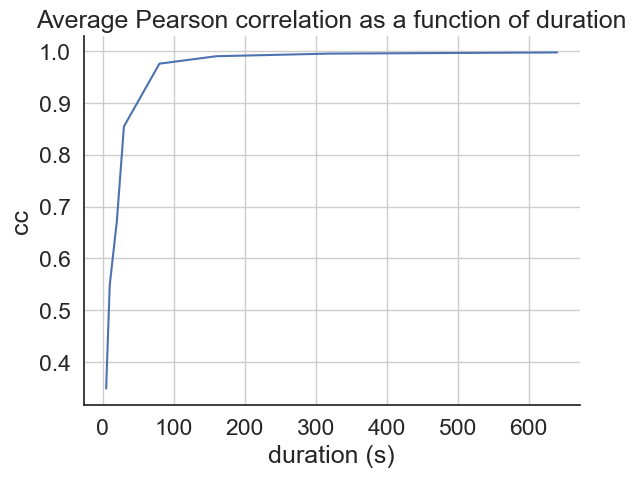

In [51]:
plt.plot(durations,ccs)
plt.xlabel('duration (s)')
plt.ylabel('cc')
plt.title('Average Pearson correlation as a function of duration')
plt.grid()

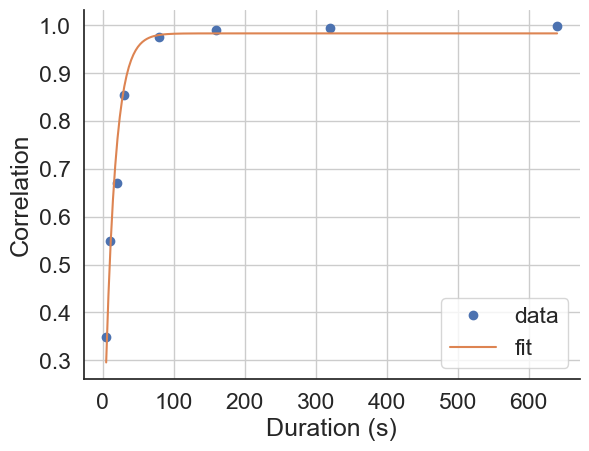

In [59]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def exp_sat(t, A, tau):
    return A * (1 - np.exp(-t/tau))

popt, _ = curve_fit(exp_sat, durations, ccs, p0=[1.0, 50])
A_hat, tau_hat = popt

t_smooth = np.linspace(min(durations), max(durations), 200)

plt.figure()
plt.plot(durations, ccs, 'o', label="data")
plt.plot(t_smooth, exp_sat(t_smooth, A_hat, tau_hat), '-', label="fit")

plt.xlabel("Duration (s)")
plt.ylabel("Correlation")
plt.legend()
plt.grid()

In [60]:
print(f'''the Pearson correlation seems to have an asymptotic exponential relationship with the duration.
      This can be characterized with the formula cc = A*(1-exp(duration/tau)) where from the fit it was found that A={A_hat} and tau={tau_hat}''')

the Pearson correlation seems to have an asymptotic exponential relationship with the duration.
      This can be characterized with the formula cc = A*(1-exp(duration/tau)) where from the fit it was found that A=0.9831549521917552 and tau=13.99637308145271


## Exercise 2
---
Determine the effect of response noise ($\sigma^2$) on RF estimates. Try different value for the noise variance in the simulations, e.g., 0, 2, 4, 6, 8, and 10 for a duration of 100 s. As in the previous excercise, repeatedly estimate RF parameters for each condition (10 times) but this time also plot the standard deviation of the correlations across the different runs for each condition.

In [ ]:
variances = [0,2,4,6,8,10]
ccs = []
stds = []
for noise_var in variances:
    cc_i = []
    for i in range(10):
        duration = 100.
        dt = .1
        std_dev = 1
        vf_size = (15,15)
        n_bins = round(duration / float(dt))


        S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])

        size = vf_size # size in pixel of our receptive field
        mu = (8, 8) # center of the gabor pathc
        sigma = (4,4) #size of the gabor patch  ## If this is the variance instead of the std.dev than the formulas below are correct otherwise they should be as I specified for the Gaussian envelope
        angle = 45 # orientation of the gabor patch
        frequency = .085 # spatial frequency of the gabor patch
        phase = 0 # pahse of the gabor pathc


        xx, yy = np.meshgrid(1. + np.arange(size[0]),
                                1. + np.arange(size[1]))

        # Gaussian envelope
        G = np.exp(- np.power(xx - mu[0], 2) / (2. * sigma[0])      ## Why aren't we using xyr here?
                    - np.power(yy - mu[1], 2) / (2. * sigma[1]))    ## Why aren't we using the equivalent to xyr for yy here? and ignoring the eccentricity?

        # Shouldn't this be:
        # G = np.exp(- np.power((xx - mu[0]) / (2. * sigma[0]), 2)
        #             - np.power((yy - mu[1]) / (2. * sigma[1]), 2))

        # spatial modulation
        phi = np.deg2rad(angle)
        xxr = xx * np.cos(phi)
        yyr = yy * np.sin(phi)
        xyr = (xxr + yyr) * 2. * np.pi * 2. * frequency     # Why multiply with 2 f ?, the formula on wikipedia just divides by lambda
        Sn = np.cos(xyr + phase)

        K = G * Sn
        K /= np.amax(np.abs(K))

        noise_variance = noise_var
        offset = 2.

        ## Generate neural responses

        # flatten the matrices in to 1d array for convenience
        K_flat = K.ravel()
        K_flat = np.hstack((K.flat, offset))   # This is what was meant by ignoring r_0

        S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))


        # 1. linear stage
        ks = np.dot(K_flat, S_flat.T)

        # 2. nonlinear stage (for a linear model: f -> identity function)
        rate = ks

        # add Gaussian noise centered around the "true" rate for each bin
        rate = rate + np.sqrt(noise_variance) * np.random.randn(n_bins)

        ## GLM fit
        #S_flat = S_flat.T
        K_hat = np.linalg.pinv(S_flat.T @ S_flat) @ (S_flat.T @ rate)
        K_hat = K_hat[:-1].reshape(vf_size)

        ## Pearson correlation:
        cc = np.inner(K.flatten(), K_hat.flatten()) / (np.linalg.norm(K.flatten()) * np.linalg.norm(K_hat.flatten()))
        cc_i.append(cc)

    ccs.append(np.mean(cc_i))
    stds.append(np.std(cc_i))

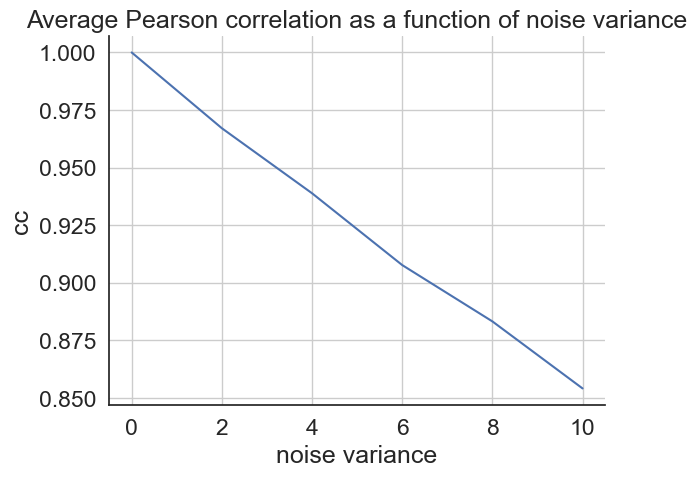

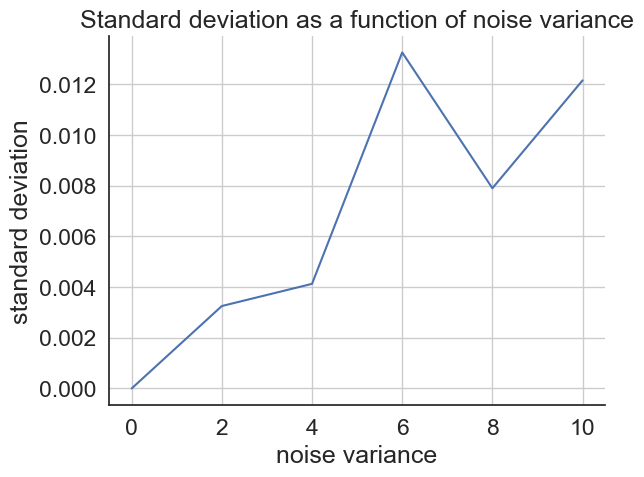

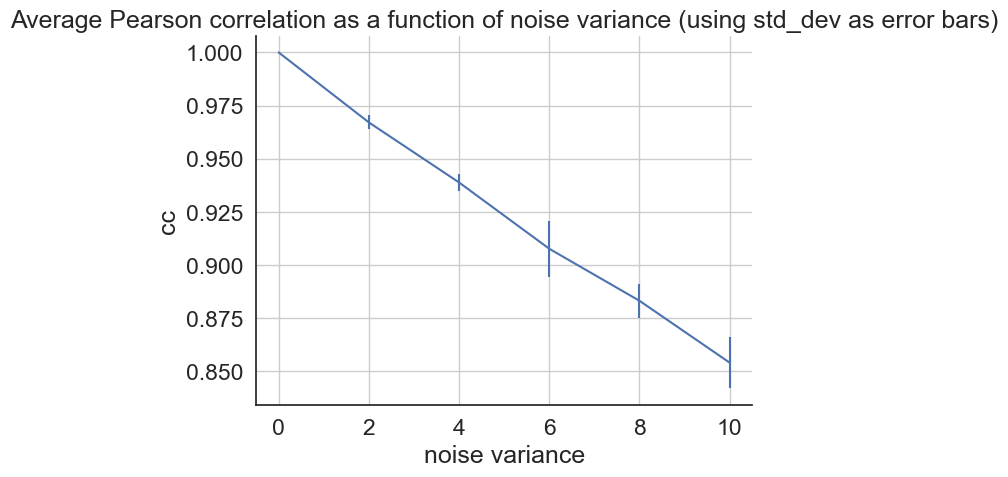

In [68]:
plt.figure()
plt.plot(variances, ccs)
plt.xlabel('noise variance')
plt.ylabel('cc')
plt.title('Average Pearson correlation as a function of noise variance')
plt.grid()

plt.figure()
plt.plot(variances, stds)
plt.xlabel('noise variance')
plt.ylabel('standard deviation')
plt.title('Standard deviation as a function of noise variance')
plt.grid()


plt.figure()
plt.errorbar(variances, ccs, yerr=stds)
plt.xlabel('noise variance')
plt.ylabel('cc')
plt.title('Average Pearson correlation as a function of noise variance (using std_dev as error bars)')
plt.grid()

## Exercise 3
---
Look at the analytical derivation of the log-likelihood for the poisson GLM.
Which of the terms are required for maximizing the likelihood with respect to $\mathbf{k}$ and which terms can be ignored? **Note:** due to the independence of spikes in the different bins, the likelihood can be written as $P(R | S, \mathbf{k}) = \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k})$. The log turns the product into a sum which makes life much easier. 




Log-likelihood for one observation:

\begin{equation*}
  P(r_t | \mathbf{s}_t, \mathbf{k}) = \frac{(\lambda_t\Delta)^{r_t}}{r_t!} e^{-\lambda_t\Delta}
\end{equation*}

And given that: 
\begin{equation*}
\log P(R | S, \mathbf{k}) = \log \prod_t^T P(r_t | \mathbf{s}_t, \mathbf{k}) = \sum_t \log P(r_t | \mathbf{s}_t, \mathbf{k})
\end{equation*}

We thus have; 

\begin{equation*}
\log P(R | S, \mathbf{k}) = \sum_t \log \frac{(\lambda_t\Delta)^{r_t}}{r_t!} e^{-\lambda_t\Delta}
\end{equation*}

This can be decomposed further by applying standard properties of logarithms:

\begin{align*}
\log P(R | S, \mathbf{k}) &= \sum_t \log \frac{(\lambda_t\Delta)^{r_t}}{r_t!} e^{-\lambda_t\Delta} \\
&= \sum_t \log \frac{(\lambda_t\Delta)^{r_t}}{r_t!} + \log e^{-\lambda_t\Delta} \\
&= \sum_t \log (\lambda_t\Delta)^{r_t} - \log r_t! + -\lambda_t\Delta \\
&= \sum_t r_t(\log \lambda_t\Delta) - \log r_t! + -\lambda_t\Delta \\
&= \sum_t  r_t\log\lambda_t + r_t \log \Delta - \log r_t! + -\lambda_t\Delta 

\end{align*}

In order to minimize this log-likelihood we can simply follow a standard optimization procedure. For which we will first need to find the derivative w.r.t. $\mathbf{k}$

\begin{align*}
    \frac{\partial{\log P(R | S, \mathbf{k})}}{\partial{\mathbf{k}}} &= \sum_t \frac{\partial{r_t \log \lambda_t}}{\partial{\mathbf{k}}} + \sum_t \frac{\partial{r_t \log \Delta}}{\partial{\mathbf{k}}} - \sum_t \frac{\partial{r_t \log r_t!}}{\partial{\mathbf{k}}} - \Delta \sum_t \frac{\partial{\lambda_t}}{\partial{\mathbf{k}}} \\
    &= \sum_t \frac{\partial{r_t \log \lambda_t}}{\partial{\mathbf{k}}} - \Delta \sum_t \frac{\partial{\lambda_t}}{\partial{\mathbf{k}}}
\end{align*}

Where the second step can be made by realizing that only $\lambda_t$ has $\mathbf{k}$-dependence. Therefore the only terms that need be considered are: 
$\sum_t r_t\log \lambda_t$ and $-\sum_t \lambda_t \Delta.$


## Exercise 4
---
Explore the effect of the data duration and the firing rate on the goodness of fit of the Poisson GLM.

A - Generate data with durations of 10,20,50,100 and 200 seconds. Fit the model on each dataset and plot the fitted parameters.
Use the pearson correlation as a proxy of the goodness of fit, and plot it as a function of the duration of the data.

B - Fix the duration to 100s, and change the average firing rate of the simulation. How does the fit perform for different firing rates? 

A.)

In [73]:
def generate_inhomogeneous_poisson_spikes(lamda, dt):

    n_bins = lamda.shape[0]
    bins = np.arange(n_bins+1)*dt

    # generate Poisson distributed numbers for all bins with the max. intensity (lamda_max)
    lamda_max = np.max(lamda)
    poisson_numbers = np.random.poisson(lamda_max, size=n_bins)

    # throw away numbers depending on the actual intensity ("thinning")
    spike_times = []
    prob = lamda / lamda_max
    for i in range(n_bins):
        
        # number of spikes to keep in this bin
        n = np.sum(np.random.rand(poisson_numbers[i]) < prob[i])
        n_s = int(round(n * dt))

        # generate random spike times in this bin
        ts = bins[i] + np.random.rand(n_s)*dt

        spike_times.extend(ts)

    return np.asarray(spike_times)

# define functions for minimisation
def cost(k, spike_counts, S,alpha=1):
    #negative loglikelihood function to minimize
    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(spike_counts, ks) + dt * np.sum(lamda)
    
    
def grad(k, spike_counts, S):
    # expression of the gradient of the negative log likelihood (note the sign is flipped accordingly)

    ks = np.dot(k, S.T)
    lamda = np.exp(ks)
    return -np.dot(S.T, spike_counts - dt*lamda)


In [79]:
# Fitting the model
from scipy.optimize import minimize
durations = [10,20,50,100,200]
ccs = []
for dur in durations:
    cc_i = []
    for i in range(10):
        # genration of the stimulus 
        duration = dur
        dt = .1
        std_dev = 1
        vf_size = (15,15)
        n_bins = round(duration / float(dt))


        S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])


        ## Generate data

        spike_rate = 5 # average firing rate 

        # flatten the matrices in to 1d array for convenience
        K_flat = K.ravel()
        K_flat = np.hstack((K.flat, offset))

        S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))


        # 1. linear stage
        ks = np.dot(K_flat, S_flat.T)

        # 2. nonlinear stage (for a linear model: f -> identity function)
        lamda = np.exp(ks)

        # lamda * dt is the number of spikes in the different bins (but keep in mind that the Poisson process
        # is a stochastic process so the actual number will differ for every draw). Thus, the sum of the product 
        # across all bins gives the expected number of spikes for the whole draw.
        expected_rate = np.sum(lamda*dt) / duration
        lamda *= (spike_rate / expected_rate)

        # generate spike times using an inhomogeneous Poisson process
        spike_times = generate_inhomogeneous_poisson_spikes(lamda, dt)

        # compute spike counts in the different time bins
        spike_counts = np.histogram(spike_times,
                                    bins=np.arange(n_bins+1)*dt)[0]

        ## Fitting the model

        k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
        res = minimize(fun = cost, x0 = k_STA / 10, args = (spike_counts, S_flat), method = 'Newton-CG', jac = grad)

        K_est = res.x

        #print("Pearson correlation = {:.3f}".format(np.inner(K.ravel(), K_est[:-1]) / (np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1]))))
        cc = np.inner(K.ravel(), K_est[:-1]) / (np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1]))
        #cc = np.inner(K.flatten(), K_hat.flatten()) / (np.linalg.norm(K.flatten()) * np.linalg.norm(K_hat.flatten()))
        cc_i.append(cc)

    ccs.append(np.mean(cc_i))



C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:38: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:39: RuntimeWarning: invalid value encountered in dot
  return -np.dot(S.T, spike_counts - dt*lamda)
C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:38: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:39: RuntimeWarning: invalid value encountered in dot
  return -np.dot(S.T, spike_counts - dt*lamda)


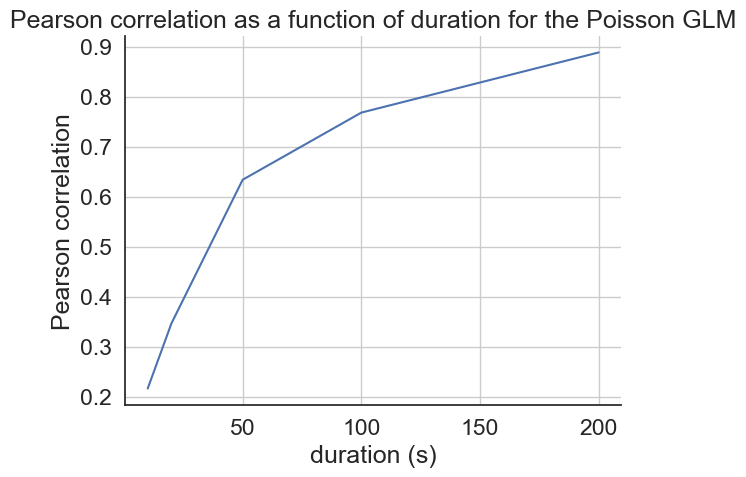

In [80]:
plt.plot(durations, ccs)
plt.xlabel('duration (s)')
plt.ylabel('Pearson correlation')
plt.title('Pearson correlation as a function of duration for the Poisson GLM')
plt.grid()

B.)

In [77]:
# Fitting the model
from scipy.optimize import minimize
firing_rates = [0,2, 5,10,20,30]
ccs = []
for f_rate in firing_rates:
    cc_i = []
    for i in range(10):
        # genration of the stimulus 
        duration = 100
        dt = .1
        std_dev = 1
        vf_size = (15,15)
        n_bins = round(duration / float(dt))


        S = std_dev * np.random.randn(n_bins,vf_size[0],vf_size[1])


        ## Generate data

        spike_rate = f_rate # average firing rate 

        # flatten the matrices in to 1d array for convenience
        K_flat = K.ravel()
        K_flat = np.hstack((K.flat, offset))

        S_flat = S.reshape(S.shape[0],S.shape[1]*S.shape[2])
        S_flat = np.hstack((S_flat, np.ones((n_bins, 1))))


        # 1. linear stage
        ks = np.dot(K_flat, S_flat.T)

        # 2. nonlinear stage (for a linear model: f -> identity function)
        lamda = np.exp(ks)

        # lamda * dt is the number of spikes in the different bins (but keep in mind that the Poisson process
        # is a stochastic process so the actual number will differ for every draw). Thus, the sum of the product 
        # across all bins gives the expected number of spikes for the whole draw.
        expected_rate = np.sum(lamda*dt) / duration
        lamda *= (spike_rate / expected_rate)

        # generate spike times using an inhomogeneous Poisson process
        spike_times = generate_inhomogeneous_poisson_spikes(lamda, dt)

        # compute spike counts in the different time bins
        spike_counts = np.histogram(spike_times,
                                    bins=np.arange(n_bins+1)*dt)[0]

        ## Fitting the model

        k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
        res = minimize(fun = cost, x0 = k_STA / 10, args = (spike_counts, S_flat), method = 'Newton-CG', jac = grad)

        K_est = res.x

        #print("Pearson correlation = {:.3f}".format(np.inner(K.ravel(), K_est[:-1]) / (np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1]))))
        cc = np.inner(K.ravel(), K_est[:-1]) / (np.linalg.norm(K.ravel()) * np.linalg.norm(K_est[:-1]))
        #cc = np.inner(K.flatten(), K_hat.flatten()) / (np.linalg.norm(K.flatten()) * np.linalg.norm(K_hat.flatten()))
        cc_i.append(cc)

    ccs.append(np.mean(cc_i))

C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:12: RuntimeWarning: invalid value encountered in divide
  prob = lamda / lamda_max
C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\873643554.py:52: RuntimeWarning: invalid value encountered in divide
  k_STA = np.inner(S_flat.T, spike_counts) / np.sum(spike_counts)
C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:38: RuntimeWarning: overflow encountered in exp
  lamda = np.exp(ks)
C:\Users\Jords\AppData\Local\Temp\ipykernel_118120\3859328750.py:39: RuntimeWarning: invalid value encountered in dot
  return -np.dot(S.T, spike_counts - dt*lamda)


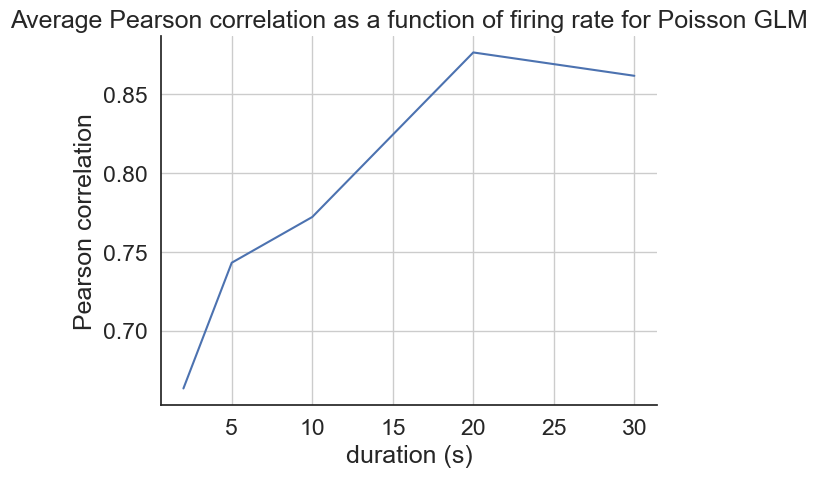

In [78]:
plt.plot(firing_rates, ccs)
plt.xlabel('duration (s)')
plt.ylabel('Pearson correlation')
plt.title('Average Pearson correlation as a function of firing rate for Poisson GLM')
plt.grid()